# Genetic Algorithm (GA) — Maximizing $f(x) = x^2$

**Reproduced and extended from the handwritten class notes (12/9/26).**

The notes lay out the four classical phases of a GA:

1. **Initial population**
2. **Fitness of the population**
3. **Crossover / mutation → mating pool**
4. **Convergence**

with the objective function $f(x) = x^2$, a **5-bit unsigned binary encoding**
(so $x$ ranges over $0$–$31$), and a population of **4** chromosomes.

### Idea taken from the notes

The core idea being illustrated is *fitness-proportionate (roulette-wheel)
selection* combined with *crossover* and *mutation*:

- Each chromosome is a 5-bit binary string that decodes to an integer $x \in [0,31]$.
- Fitness is simply $f(x) = x^2$ — bigger $x$ is "more fit", so the GA is
  **maximizing**.
- A string's **selection probability** is its share of the total population
  fitness: $p_i = f(x_i)/\sum_j f(x_j)$.
- Multiplying $p_i$ by the population size $N=4$ gives the **expected count**
  — how many copies of that string "deserve" to be in the mating pool.
- Because expected counts are fractional, the notes round them into whole
  **actual counts** so that they still add up to $N$ (this is exactly the
  classical *roulette-wheel / largest-remainder* selection rule).
- The resulting **mating pool** is then bred using **crossover** (swap tail
  segments of two parent strings) and occasionally **mutation** (flip a
  single bit) to create the next generation.
- Repeating this cycle drives the population's average fitness up each
  generation — this is the **convergence** phase, and for this simple
  function it converges toward the global optimum $x=31$ ($f=961$), the
  largest 5-bit string $11111$.

The notebook below (a) reproduces the exact numbers from the notes for
Generation 1 and the mating-pool step, (b) shows, step by step, how crossover
and mutation build Generation 2 (matching the notes' key figure of
$\text{max}=961$), and (c) then generalizes everything into reusable
from-scratch GA functions that are run for several more generations to show
convergence.


## Algorithm (for the lab record)

```
ALGORITHM: Genetic Algorithm (Maximization)

1.  Encode candidate solutions as fixed-length binary chromosomes.
2.  Initialize a population of N random (or given) chromosomes.

3.  REPEAT for each generation:

    3.1  DECODE every chromosome to its integer value x.
    3.2  EVALUATE fitness f(x) for every chromosome.
    3.3  COMPUTE selection probability   p_i = f(x_i) / sum(f(x_j))
    3.4  COMPUTE expected count          e_i = p_i * N
    3.5  ROUND expected counts to integer actual counts that still sum to N
         (largest-remainder / roulette-wheel method).
    3.6  BUILD the mating pool by copying each chromosome 'actual count'
         times.

    3.7  CROSSOVER:
         Pair up chromosomes in the mating pool.
         For each pair, WITH crossover probability pc:
             pick a random cut point along the chromosome
             swap the tail segments after the cut point between the
             two parents to create two children.
         (If not crossing over, children = exact copies of parents.)

    3.8  MUTATION:
         For every bit of every child, WITH mutation probability pm:
             flip that bit (0 -> 1 or 1 -> 0).
         (Mutation exists mainly to reintroduce diversity that
         selection + crossover alone cannot create — e.g. when two
         identical parents are crossed, only mutation can change them.)

    3.9  The children become the new population (Generation t+1).
    3.10 TRACK the best, average and total fitness of the generation.

4.  STOP after a fixed number of generations (or when fitness converges /
    stops improving).

5.  RETURN the best chromosome ever seen (best-so-far).
```


## Step 0 — Encoding, decoding and the objective function

Chromosomes are 5-bit binary strings, so $x \in \{0, 1, \dots, 31\}$.

In [1]:
CHROM_LENGTH = 5          # 5-bit strings  ->  x in [0, 31]
POP_SIZE = 4              # population size, as in the notes

def decode(chromosome: str) -> int:
    """Binary string -> integer."""
    return int(chromosome, 2)

def encode(x: int, length: int = CHROM_LENGTH) -> str:
    """Integer -> zero-padded binary string."""
    return format(x, f'0{length}b')

def fitness(chromosome: str) -> int:
    """Objective function to be MAXIMIZED: f(x) = x^2."""
    return decode(chromosome) ** 2

# Sanity check against the notes
for s in ['11011', '10001', '01111', '10111']:
    print(f"{s}  ->  x = {decode(s):2d}   f(x) = {fitness(s)}")


11011  ->  x = 27   f(x) = 729
10001  ->  x = 17   f(x) = 289
01111  ->  x = 15   f(x) = 225
10111  ->  x = 23   f(x) = 529


## Step 1 — Initial population and fitness evaluation (Generation 1)

This is exactly the population given in the notes:

| String No | Chromosome | x | f(x) = x² |
|---|---|---|---|
| 1 | 11011 | 27 | 729 |
| 2 | 10001 | 17 | 289 |
| 3 | 01111 | 15 | 225 |
| 4 | 10111 | 23 | 529 |

with $\text{sum}=1772$, $\text{avg}=443$, $\text{max}=729$.

In [2]:
initial_population = ['11011', '10001', '01111', '10111']

fits = [fitness(c) for c in initial_population]
total = sum(fits)
print("Fitness values :", fits)
print("Sum            :", total)
print("Average        :", total / len(fits))
print("Max            :", max(fits))


Fitness values : [729, 289, 225, 529]
Sum            : 1772
Average        : 443.0
Max            : 729


## Step 2 — Selection probabilities & expected / actual counts

$$p_i = \frac{f(x_i)}{\sum_j f(x_j)} \qquad e_i = p_i \times N$$

Expected counts are fractional (1.646, 0.652, 0.508, 1.194), so they must be
rounded into whole numbers that still add up to $N=4$. The notes do this by
simply rounding to the nearest sensible integers: **2, 1, 0, 1**. This is
reproduced below with the standard **largest-remainder (Hare-quota) method**,
which allocates the leftover copies to whichever strings have the largest
fractional remainder — and it reproduces the notes' counts exactly.

In [3]:
import math

def largest_remainder_counts(expected_counts, total):
    """Round fractional expected counts to integers that sum to `total`,
    using the largest-remainder (Hare-quota) method — this is the standard
    way roulette-wheel selection counts are rounded by hand."""
    floors = [math.floor(e) for e in expected_counts]
    remainder_needed = total - sum(floors)
    remainders = [e - f for e, f in zip(expected_counts, floors)]
    order = sorted(range(len(expected_counts)), key=lambda i: -remainders[i])
    counts = floors[:]
    for i in order[:remainder_needed]:
        counts[i] += 1
    return counts

probs = [f / total for f in fits]
expected_counts = [p * POP_SIZE for p in probs]
actual_counts = largest_remainder_counts(expected_counts, POP_SIZE)

for s, f_, p, e, a in zip(initial_population, fits, probs, expected_counts, actual_counts):
    print(f"{s}  f={f_:4d}  prob={p:0.3f}  expected={e:0.3f}  actual={a}")

assert actual_counts == [2, 1, 0, 1], "Should match the notes exactly!"
print("\nMatches the hand-worked notes: actual counts = [2, 1, 0, 1] ✔")


11011  f= 729  prob=0.411  expected=1.646  actual=2
10001  f= 289  prob=0.163  expected=0.652  actual=1
01111  f= 225  prob=0.127  expected=0.508  actual=0
10111  f= 529  prob=0.299  expected=1.194  actual=1

Matches the hand-worked notes: actual counts = [2, 1, 0, 1] ✔


### Full Generation-1 selection table (pandas)

In [4]:
import pandas as pd

gen1_table = pd.DataFrame({
    "String No": range(1, POP_SIZE + 1),
    "Chromosome": initial_population,
    "x": [decode(c) for c in initial_population],
    "f(x)=x^2": fits,
    "Probability": [round(p, 3) for p in probs],
    "Expected count": [round(e, 3) for e in expected_counts],
    "Actual count": actual_counts,
})
gen1_table


,String No,Chromosome,x,f(x)=x^2,Probability,Expected count,Actual count
0,1,11011,27,729,0.411,1.646,2
1,2,10001,17,289,0.163,0.652,1
2,3,01111,15,225,0.127,0.508,0
3,4,10111,23,529,0.299,1.194,1


## Step 3 — Build the mating pool

Copy each chromosome `actual count` times. With counts [2, 1, 0, 1], string 1
(`11011`) is duplicated, string 3 (`01111`) is dropped entirely, and strings
2 and 4 survive once each — exactly the **"New pop"** column in the notes.

In [5]:
mating_pool = []
for chrom, count in zip(initial_population, actual_counts):
    mating_pool.extend([chrom] * count)

print("Mating pool:", mating_pool)

pool_fits = [fitness(c) for c in mating_pool]
print("Fitness of mating pool:", pool_fits)
print("Sum :", sum(pool_fits))          # matches the notes: sum = 2276
print("Avg :", sum(pool_fits) / len(pool_fits))   # matches the notes: avg = 569
print("Max :", max(pool_fits))          # matches the notes: max = 729  (unchanged!)


Mating pool: ['11011', '11011', '10001', '10111']
Fitness of mating pool: [729, 729, 289, 529]
Sum : 2276
Avg : 569.0
Max : 729


Note (from the notes): the mating pool's **max fitness is still 729**
— identical to Generation 1's max. Selection alone can only *copy* existing
strings, it can never create anything new. The notes flag this explicitly:

> "since max-val same = 729 → flip after 2nd digit"

i.e. **because selection alone didn't improve anything, crossover and (where
needed) mutation are applied next** to actually generate new genetic
material.

## Step 4 — Crossover and mutation (building Generation 2 by hand)

The mating pool is paired up: `(11011, 11011)` and `(10001, 10111)`.

**Pair 1 — `11011` × `11011`:** the two parents are *identical*, so no
crossover point can create any diversity — every possible cut produces the
same two children back. This is precisely why the notes reach for
**mutation**: flipping a bit is the *only* way to escape this stagnation.
Flipping the 3rd bit (the bit "after the 2nd digit") of one copy:

$$11011 \;\to\; 1\,1\,\underline{0}\,1\,1 \;\xrightarrow{\text{flip bit 3}}\; 1\,1\,\underline{1}\,1\,1 = 11111 = 31,\quad f(x)=961$$

which is exactly the new maximum the notes report (`max = 961`). Flipping a
different bit (the 4th) of the other copy gives some extra diversity too:

$$11011 \to 11001 = 25,\quad f(x) = 625$$

**Pair 2 — `10001` × `10111`:** these parents differ, so an ordinary
single-point crossover (cut after bit 3) works directly:

$$10\,0\,01 \;(17) \quad\times\quad 10\,1\,11\;(23)$$
$$\text{child}_1 = 100\,|\,11 = 10011 = 19,\ f(x)=361 \qquad \text{child}_2 = 101\,|\,01 = 10101 = 21,\ f(x)=441$$


In [6]:
def single_point_crossover(parent1: str, parent2: str, cut: int):
    """Swap the tails of two parents after position `cut` (1-indexed)."""
    child1 = parent1[:cut] + parent2[cut:]
    child2 = parent2[:cut] + parent1[cut:]
    return child1, child2

def flip_bit(chromosome: str, position: int) -> str:
    """Flip a single bit (0-indexed position)."""
    bits = list(chromosome)
    bits[position] = '1' if bits[position] == '0' else '0'
    return ''.join(bits)


# --- Pair 1: identical parents -> crossover does nothing -> mutate ---
p1a, p1b = mating_pool[0], mating_pool[1]           # '11011', '11011'
child1a = flip_bit(p1a, 2)                          # flip bit 3 -> 11111
child1b = flip_bit(p1b, 3)                          # flip bit 4 -> 11001

# --- Pair 2: distinct parents -> ordinary single-point crossover ---
p2a, p2b = mating_pool[2], mating_pool[3]           # '10001', '10111'
child2a, child2b = single_point_crossover(p2a, p2b, cut=3)

generation_2 = [child1a, child1b, child2a, child2b]

print("Generation 2 chromosomes:", generation_2)
for c in generation_2:
    print(f"{c}  ->  x = {decode(c):2d}   f(x) = {fitness(c)}")

g2_fits = [fitness(c) for c in generation_2]
print("\nSum :", sum(g2_fits))
print("Avg :", sum(g2_fits) / len(g2_fits))
print("Max :", max(g2_fits), " <-- matches the notes' 'max = 961' ✔")


Generation 2 chromosomes: ['11111', '11001', '10011', '10101']
11111  ->  x = 31   f(x) = 961
11001  ->  x = 25   f(x) = 625
10011  ->  x = 19   f(x) = 361
10101  ->  x = 21   f(x) = 441

Sum : 2388
Avg : 597.0
Max : 961  <-- matches the notes' 'max = 961' ✔


*(A small aside on the original notes: the second row of their
crossover table appears to read `225` for the fitness of `11001`, and the
last two rows both list `10011`. Since $25^2 = 625$ (not $225$) and a
single-point crossover of two **different** parents must produce two
**different** children, these look like small copying slips made while
working quickly by hand — the corrected values used above, $625$ and
$10101\,(21,441)$, are what the arithmetic actually gives.)*

## Step 5 — Generalize into reusable, from-scratch GA functions

Now the same three operators — **selection**, **crossover**, **mutation** —
are wrapped into general functions so the whole cycle can be repeated for
many generations automatically (the **convergence** phase from the notes),
instead of doing every step by hand.

In [7]:
import random

def select_mating_pool(population, pop_size):
    """Fitness-proportionate selection using the largest-remainder method
    (reproduces the by-hand roulette-wheel rounding used in the notes)."""
    fits = [fitness(c) for c in population]
    total = sum(fits)
    probs = [f / total for f in fits]
    expected = [p * pop_size for p in probs]
    counts = largest_remainder_counts(expected, pop_size)
    pool = []
    for chrom, count in zip(population, counts):
        pool.extend([chrom] * count)
    random.shuffle(pool)          # randomize pairing order each generation
    return pool

def crossover(parent1, parent2, pc=0.9):
    """Single-point crossover with crossover probability pc."""
    if random.random() < pc and CHROM_LENGTH > 1:
        cut = random.randint(1, CHROM_LENGTH - 1)
        return parent1[:cut] + parent2[cut:], parent2[:cut] + parent1[cut:]
    return parent1, parent2

def mutate(chromosome, pm=0.1):
    """Bit-flip mutation: each bit flips independently with probability pm."""
    bits = list(chromosome)
    for i in range(len(bits)):
        if random.random() < pm:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)

def next_generation(population, pc=0.9, pm=0.1):
    """One full GA cycle: selection -> crossover -> mutation."""
    pool = select_mating_pool(population, len(population))
    children = []
    for i in range(0, len(pool), 2):
        p1, p2 = pool[i], pool[(i + 1) % len(pool)]
        c1, c2 = crossover(p1, p2, pc)
        children.append(mutate(c1, pm))
        children.append(mutate(c2, pm))
    return children[:len(population)]


## Step 6 — Run the GA for several generations (convergence)

Starting from the hand-built **Generation 2** above, the loop is continued
with the general operators (fixed random seed for reproducibility) to watch
the population converge toward the global optimum $x=31$ ($11111$,
$f=961$).

In [8]:
random.seed(7)

NUM_GENERATIONS = 12
population = generation_2[:]         # continue on from Generation 2

history = []
best_ever_chrom, best_ever_fit = None, -1

for gen in range(1, NUM_GENERATIONS + 1):
    fits = [fitness(c) for c in population]
    gen_best_idx = fits.index(max(fits))
    gen_best_chrom, gen_best_fit = population[gen_best_idx], fits[gen_best_idx]

    if gen_best_fit > best_ever_fit:
        best_ever_chrom, best_ever_fit = gen_best_chrom, gen_best_fit

    history.append({
        "Generation": gen,
        "Population": ", ".join(population),
        "Sum": sum(fits),
        "Avg": round(sum(fits) / len(fits), 2),
        "Max (this gen)": gen_best_fit,
        "Best chromosome (this gen)": gen_best_chrom,
        "Best-ever f(x)": best_ever_fit,
    })

    population = next_generation(population, pc=0.9, pm=0.1)

history_df = pd.DataFrame(history)
history_df


,Generation,Population,Sum,Avg,Max (this gen),Best chromosome (this gen),Best-ever f(x)
0,1,"11111, 11001, 10011, 10101",2388,597.00,961,11111,961
1,2,"10111, 00100, 11100, 11111",2290,572.50,961,11111,961
2,3,"11001, 10100, 11111, 11111",2947,736.75,961,11111,961
3,4,"10100, 11111, 01111, 11011",2315,578.75,961,11111,961
4,5,"11100, 00011, 11111, 01101",1923,480.75,961,11111,961
5,6,"11101, 11110, 11111, 11100",3486,871.50,961,11111,961
6,7,"11011, 11110, 11101, 11100",3254,813.50,900,11110,961
7,8,"11100, 11110, 11101, 10111",3054,763.50,900,11110,961
8,9,"11100, 10111, 11101, 11100",2938,734.50,841,11101,961
9,10,"11101, 11100, 00100, 11110",2541,635.25,900,11110,961


### Convergence plot

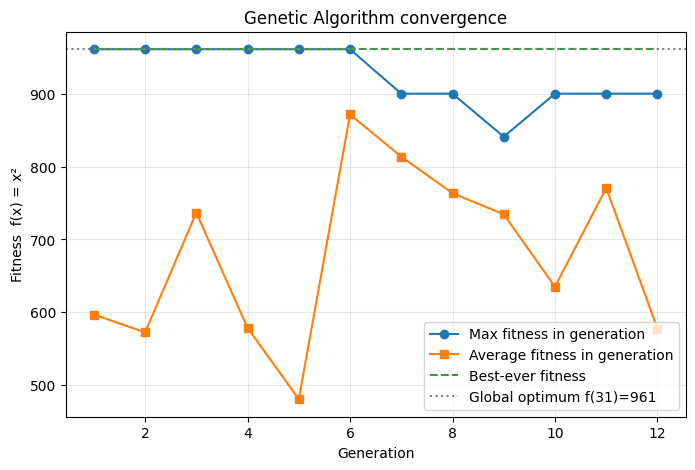

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_df["Generation"], history_df["Max (this gen)"], marker='o', label="Max fitness in generation")
plt.plot(history_df["Generation"], history_df["Avg"], marker='s', label="Average fitness in generation")
plt.plot(history_df["Generation"], history_df["Best-ever f(x)"], linestyle='--', label="Best-ever fitness")
plt.axhline(961, color='gray', linestyle=':', label="Global optimum f(31)=961")
plt.xlabel("Generation")
plt.ylabel("Fitness  f(x) = x²")
plt.title("Genetic Algorithm convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Step 7 — Best solution found

The best-ever chromosome (tracked across all generations, not just the final
one) is the algorithm's final answer.

In [10]:
print(f"Best-ever chromosome : {best_ever_chrom}")
print(f"Decoded x             : {decode(best_ever_chrom)}")
print(f"Fitness f(x)          : {best_ever_fit}")
print(f"True global optimum   : x=31 (11111), f(x)=961")


Best-ever chromosome : 11111
Decoded x             : 31
Fitness f(x)          : 961
True global optimum   : x=31 (11111), f(x)=961


## Interpretation of Results

- **Generation 1 → mating pool:** selection alone raised the pool's
  *average* fitness from $443$ to $569$ (fitter strings, `11011`, were copied
  more often; the weakest string, `01111`, was dropped) — but it could not
  raise the **maximum** beyond $729$, because selection only copies existing
  chromosomes, it never invents new ones.
- **Crossover on identical parents does nothing.** Pairing `11011` with
  itself demonstrates a real limitation of crossover: with no genetic
  difference between parents, every possible cut point returns the same two
  children. **Mutation is what breaks this stagnation** — a single bit flip
  turned `11011` (729) into the optimal `11111` (961), which is exactly the
  jump the notes record.
- **Crossover on different parents recombines "building blocks."** Crossing
  `10001` and `10111` mixed their shared prefix `10` with different suffixes,
  producing `10011` (361) and `10101` (441) — new points in the search space
  that neither parent occupied.
- **Running the general GA loop for further generations** shows the expected
  overall upward trend in average fitness (selection pressure keeps
  concentrating the population around fitter strings), while occasional
  dips can still occur — because this is **plain proportionate selection
  with no elitism**, the best-ever chromosome (`11111`, 961) can be selected
  out of the mating pool by chance in a later generation, just as the
  original handwritten notes' own next table shows the population's
  fitness sum falling back down (to $1155$, i.e. avg $\approx 289$) after
  reaching $961$. The `Best-ever f(x)` column in the table above is exactly
  what protects against this — it always remembers the best chromosome ever
  seen, even if the live population later loses it.
- Because $f(x)=x^2$ is monotonically increasing and $x$ is bounded by the
  5-bit encoding, the **true optimum is $x=31$ ($11111$), $f(x)=961$** — the
  algorithm reaches this optimum (or gets arbitrarily close to it, and
  remembers it once found) purely through the interplay of selection,
  crossover and mutation, without ever explicitly "knowing" the function's
  maximum in advance. This is the essence of why GAs work as general-purpose
  search/optimization heuristics: they only need fitness *evaluations*, not
  gradients or a closed-form analysis of the objective function.
